https://aviationweather.gov/data/api/

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
flights = pd.read_csv('datasets/flights_sample_100k.csv')

In [112]:
flights

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-03-01,Allegiant Air,Allegiant Air: G4,G4,20368,1668,PGD,"Punta Gorda, FL",SPI,"Springfield, IL",...,0.0,160.0,138.0,122.0,994.0,NaN,NaN,NaN,NaN,NaN
1,2021-02-16,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2437,DFW,"Dallas/Fort Worth, TX",LAX,"Los Angeles, CA",...,0.0,211.0,NaN,NaN,1235.0,NaN,NaN,NaN,NaN,NaN
2,2022-04-12,PSA Airlines Inc.,PSA Airlines Inc.: OH,OH,20397,5560,EWN,"New Bern/Morehead/Beaufort, NC",CLT,"Charlotte, NC",...,0.0,79.0,78.0,51.0,221.0,NaN,NaN,NaN,NaN,NaN
3,2021-10-13,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1944,ABQ,"Albuquerque, NM",DEN,"Denver, CO",...,0.0,80.0,71.0,49.0,349.0,10.0,0.0,0.0,0.0,6.0
4,2022-06-05,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,3081,PIT,"Pittsburgh, PA",STL,"St. Louis, MO",...,0.0,105.0,100.0,82.0,554.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2019-02-26,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2229,CHS,"Charleston, SC",ATL,"Atlanta, GA",...,0.0,84.0,73.0,50.0,259.0,NaN,NaN,NaN,NaN,NaN
99996,2023-02-10,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2977,MDW,"Chicago, IL",LAX,"Los Angeles, CA",...,0.0,280.0,239.0,209.0,1750.0,88.0,0.0,0.0,0.0,0.0
99997,2019-06-26,Endeavor Air Inc.,Endeavor Air Inc.: 9E,9E,20363,5003,ORF,"Norfolk, VA",JFK,"New York, NY",...,0.0,93.0,82.0,51.0,290.0,NaN,NaN,NaN,NaN,NaN
99998,2023-06-22,Endeavor Air Inc.,Endeavor Air Inc.: 9E,9E,20363,5173,CVG,"Cincinnati, OH",LGA,"New York, NY",...,0.0,127.0,110.0,87.0,585.0,NaN,NaN,NaN,NaN,NaN


In [117]:
import os
import airportsdata
import geopandas as gpd
import shapely

stations = pd.read_csv("datasets/ghcnd-stations.txt", delimiter=" ", skipinitialspace=True, usecols=[0,1,2,3], names=["Station", "Latitude", "Longitude", "Altitude"])
stations.head()

used = [i[:-4] for i in os.listdir("/Volumes/McDrive/daily-summaries-latest/")]
stations = stations[stations["Station"].isin(used)]

In [121]:
iata = airportsdata.load('iata')
# Projection using standard for geographic coordinate systems using latitude and longitude.
stations_geo = gpd.GeoDataFrame(stations, geometry=gpd.points_from_xy(stations.Longitude, stations.Latitude, stations.Altitude), crs="EPSG:4326")
stations_geo.drop(columns=["Latitude", "Longitude", "Altitude"], inplace=True)
def get_airport_coords(iata_code):
    airport = iata.get(iata_code)
    if airport:
        lat, long, elv = airport['lat'], airport['lon'], airport['elevation']
        return shapely.geometry.Point(long, lat, elv)
    else:
        # ISN is not included in dataset added via wikipedia
        return shapely.geometry.Point(-103.642222, 48.178056, 1982)

In [175]:
iata_codes = (pd.concat([flights["ORIGIN"], flights["DEST"]])).unique()
iata_geo = gpd.GeoDataFrame(iata_codes, geometry=list(map(get_airport_coords, iata_codes)), crs="EPSG:4326")
# Set projection to US USA Contiguous Albers Equal Area Conic projection
iata_geo = iata_geo.to_crs("ESRI:102003")
stations_geo = stations_geo.to_crs("ESRI:102003")
iata_geo = iata_geo.sjoin_nearest(stations_geo, lsuffix="Airport", rsuffix="Station", distance_col="distances")
iata_geo["station_geometry"] = iata_geo["Station"].map(stations_geo.set_index("Station").geometry)
iata_station = {i[1][0]: i[1]["Station"] for i in iata_geo.iterrows()}
iata_geo.head()

,0,geometry,index_Station,Station,Altitude,distances,station_geometry
0,PGD,POINT Z (1395386.707 -1075026.07 25.5),127256,USW00012812,6.1,303.012015,POINT Z (1395093.394 -1075102.118 6.1)
1,DFW,POINT Z (-96493.055 -514433.559 606.4),127120,USW00003927,165.8,1469.072361,POINT Z (-95024.048 -514419.683 165.8)
2,EWN,POINT Z (1702959.629 -101417.375 17.9),128536,USW00093719,3.4,668.218206,POINT Z (1702636.885 -102002.483 3.4)
3,ABQ,POINT Z (-957751.676 -222118.448 5354.9),127798,USW00023050,1618.5,742.294676,POINT Z (-958374.401 -221714.449 1618.5)
4,PIT,POINT Z (1319065.433 444922.839 1202.9),128776,USW00094823,341.1,1711.786857,POINT Z (1320706.19 444434.852 341.1)


In [124]:
frames = []
for file in iata_station.values():
    df = pd.read_csv(f'/Volumes/McDrive/daily-summaries-latest/{file}.csv')
    frames.append(df)
weather = pd.concat(frames, ignore_index=True)

In [ ]:
# for i in flights.iterrows():
#     date, origin, dest = i[1]["FL_DATE"], i[1]["ORIGIN"], i[1]["DEST"]
#
#     if not (any(weather[weather["STATION"] == iata_station[origin]]["DATE"] == date) or any(weather[weather["STATION"] == iata_station[dest]]["DATE"] == date)):
#         print(date, origin, dest, end=": ")
#         print(iata_station[origin], iata_station[dest])

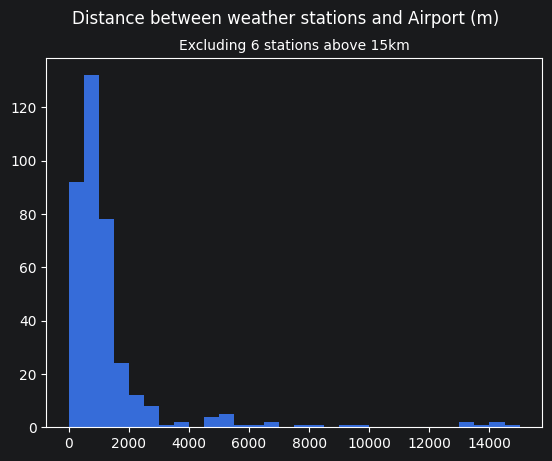

In [165]:
plt.hist(iata_geo["distances"], range=(-1, 15000), bins=30)
plt.suptitle("Distance between weather stations and Airport (m)")
excluded = (iata_geo["distances"] > 15000).sum()
plt.title(f"Excluding {excluded} stations above 15km", fontsize=10)
plt.show()

In [166]:
iata_geo[iata_geo["distances"] > 15_000]

,0,geometry,index_Station,Station,Altitude,distances,station_geometry
221,LBE,POINT Z (1391428.299 432547.273 1198.7),117353,USC00362183,548.6,16316.764546,POINT Z (1394637.958 416549.308 548.6)
296,SHD,POINT Z (1474378.006 218644.613 1201),97515,US1VAAG0006,486.5,18940.024976,POINT Z (1461486.604 204768.868 486.5)
313,ADK,POINT Z (-5046890.881 3875781.542 19.5),128104,USW00025713,7.9,709067.127247,POINT Z (-4341012.893 3942956.365 7.9)
338,WRG,POINT Z (-2328751.365 2537216.539 44),128070,USW00025329,32.6,50033.420118,POINT Z (-2350537.782 2582257.578 32.6)
340,DLG,POINT Z (-3650685.781 3596114.22 82),128084,USW00025503,43.9,123985.594726,POINT Z (-3578864.893 3495048.955 43.9)
368,MMH,POINT Z (-1977506.13 252674.507 7134.8),125125,USR0000CROC,2145.8,17072.085111,POINT Z (-1964860.069 241205.713 2145.8)


In [169]:
flights["ORIGIN_STATION"] = flights["ORIGIN"].map(iata_station)
flights["DEST_STATION"] = flights["DEST"].map(iata_station)

In [172]:
# Join origin weather
flights = flights.merge(
    weather.add_prefix("ORIGIN_"),
    left_on=["FL_DATE", "ORIGIN_STATION"],
    right_on=["ORIGIN_DATE", "ORIGIN_STATION"],
    how="left"
)

# Join destination weather
flights = flights.merge(
    weather.add_prefix("DEST_"),
    left_on=["FL_DATE", "DEST_STATION"],
    right_on=["DEST_DATE", "DEST_STATION"],
    how="left"
)

In [174]:
flights.to_csv("datasets/flight_weather_sample_100k.csv", index=False)